<a href="https://colab.research.google.com/github/neuish/Stok-Market-Analysis/blob/main/Stock_Market_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [107]:
#importing essential libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [108]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [109]:
df = pd.read_csv('/content/drive/MyDrive/Python Projects/floorsheet.tsv', sep='\t')

In [110]:
df.head(20)

,ts,cid,nid,symbol,buyer,seller,volume,rate,amount
0,2024-11-25T10:46:00.002865,2024112501000001,131,NABIL,56,74,10,569.1,5691.0
1,2024-11-25T10:46:00.012527,2024112501000002,134,HBL,56,19,10,257.0,2570.0
2,2024-11-25T10:46:00.015159,2024112501000003,135,SBI,93,10,10,468.1,4681.0
3,2024-11-25T10:46:00.019797,2024112501000004,139,NICA,56,48,10,435.5,4355.0
4,2024-11-25T10:46:00.022646,2024112501000005,140,MBL,56,45,10,264.9,2649.0
5,2024-11-25T10:46:00.025414,2024112501000006,141,LSL,56,58,10,252.9,2529.0
6,2024-11-25T10:46:00.027936,2024112501000007,142,KBL,56,58,10,222.3,2223.0
7,2024-11-25T10:46:00.02798,2024112501000008,142,KBL,93,58,10,222.3,2223.0
8,2024-11-25T10:46:00.030521,2024112501000009,145,SBL,56,29,10,330.4,3304.0
9,2024-11-25T10:46:00.03267,2024112501000010,171,SANIMA,56,94,10,308.0,3080.0


In [111]:
df['ts'] = pd.to_datetime(df['ts'], format='ISO8601', errors='coerce')

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65824 entries, 0 to 65823
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ts      65824 non-null  datetime64[ns]
 1   cid     65824 non-null  int64         
 2   nid     65824 non-null  int64         
 3   symbol  65824 non-null  object        
 4   buyer   65824 non-null  int64         
 5   seller  65824 non-null  int64         
 6   volume  65824 non-null  int64         
 7   rate    65824 non-null  float64       
 8   amount  65824 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(5), object(1)
memory usage: 4.5+ MB


In [113]:
df.describe()

,ts,cid,nid,buyer,seller,volume,rate,amount
count,65824,6.582400e+04,65824.000000,65824.000000,65824.000000,65824.000000,65824.000000,6.582400e+04
mean,2024-11-25 13:18:03.941613568,2.024113e+15,3739.403500,42.744744,41.989806,186.311680,710.747739,9.640571e+04
min,2024-11-25 10:46:00.002865,2.024113e+15,131.000000,1.000000,1.000000,1.000000,8.670000,2.130000e+02
25%,2024-11-25 12:20:08.499419136,2.024113e+15,357.000000,29.000000,28.000000,15.000000,418.100000,1.010000e+04
50%,2024-11-25 13:22:05.428423680,2.024113e+15,2788.000000,44.000000,43.000000,54.000000,576.200000,3.454000e+04
75%,2024-11-25 14:22:15.305793792,2.024113e+15,8066.000000,57.000000,57.000000,175.000000,846.900000,9.675000e+04
max,2024-11-25 14:59:59.878216,2.024113e+15,9244.000000,101.000000,101.000000,98000.000000,47938.600000,2.611648e+07
std,NaN,1.471920e+06,3595.617884,20.920332,20.559196,789.307614,912.462365,2.722221e+05


In [114]:
df.columns = df.columns.str.capitalize()


In [115]:
total_turnover = df['Amount'].sum()
print(f"Total Turnover: {total_turnover:,.2f}")


Total Turnover: 6,345,809,597.84


In [116]:
total_traded_shares = df['Volume'].sum()
print(f"Total Traded Shares: {total_traded_shares:,}")

Total Traded Shares: 12,263,780


In [117]:
total_transactions = len(df)
print(f"Total Transactions: {total_transactions:,}")

Total Transactions: 65,824


In [118]:
total_stock_traded = df['Symbol'].nunique()
print(f"Total Stock Traded: {total_stock_traded}")


Total Stock Traded: 309


In [119]:
# Combine unique buyer and seller IDs
unique_buyers = df['Buyer'].unique()
unique_sellers = df['Seller'].unique()

# Use set union to avoid double counting
total_brokers = len(set(unique_buyers) | set(unique_sellers))
print(f"Total Trading Brokers: {total_brokers}")


Total Trading Brokers: 92


In [120]:
# Convert timestamp to datetime (if not already)
df['Ts'] = pd.to_datetime(df['Ts'])

# Extract the date from timestamp
df['Date'] = df['Ts'].dt.date

# Sort the DataFrame by timestamp to get correct Open and Close
df = df.sort_values(['Symbol', 'Date', 'Ts'])

# Group and aggregate
summary = df.groupby(['Symbol', 'Date']).agg(
    Open=('Rate', 'first'),
    High=('Rate', 'max'),
    Low=('Rate', 'min'),
    Close=('Rate', 'last'),
    Volume=('Volume', 'sum')
).reset_index()

summary.head(20)


,Symbol,Date,Open,High,Low,Close,Volume
0,ACLBSL,2024-11-25,1113.0,1130.0,1113.0,1116.0,1180
1,ADBL,2024-11-25,357.0,357.0,343.7,351.9,32139
2,ADBLD83,2024-11-25,1140.0,1140.0,1135.0,1135.0,400
3,AHL,2024-11-25,689.0,702.0,687.2,700.0,5440
4,AHPC,2024-11-25,282.0,283.0,273.5,281.0,125195
5,AKJCL,2024-11-25,211.0,211.0,207.0,207.5,154709
6,AKPL,2024-11-25,259.1,260.0,249.9,255.0,148166
7,ALBSL,2024-11-25,855.5,877.0,850.6,875.0,3282
8,ALICL,2024-11-25,725.1,736.0,725.1,735.0,32858
9,ANLB,2024-11-25,4861.0,5145.0,4851.0,5111.2,13543


In [121]:
most_traded_stocks = df.groupby('Symbol')['Volume'].sum().sort_values(ascending=False).head(10)
print(most_traded_stocks)


Symbol
NGPL      1077685
HURJA      315981
BFC        301419
SAEF       242292
RHPL       196446
KBL        175979
SHEL       173581
HIDCLP     170319
SHPC       169231
MBJC       164437
Name: Volume, dtype: int64


In [122]:
most_active_stock_by_volume = df.groupby('Symbol')['Volume'].max().sort_values(ascending=False).head(10)
print(most_active_stock_by_volume)


Symbol
SBCF      98000
SIGS3     50000
SAEF      50000
NICGF2    48500
PHCL      30674
SMHL      27520
USHEC     26000
GIBF1     25000
RFPL      25000
SEF       25000
Name: Volume, dtype: int64


In [123]:
df['Value'] = df['Volume'] * df['Rate']
most_active_stock_by_value = df.groupby('Symbol')['Value'].sum().sort_values(ascending=False).head(10)
print(most_active_stock_by_value)


Symbol
NGPL      540750678.9
BFC       252967779.5
NFS       203107920.6
NRN       156465713.2
HATHY     150865836.1
JFL       135321963.0
SMHL      125529346.4
SAPDBL    116740615.6
KRBL      102785064.9
PFL       102409167.3
Name: Value, dtype: float64


In [124]:
# Biggest Intraday Price Percentage Change Increase in Stock
# Create a daily summary for calculating percentage change
daily_summary = df.groupby(['Symbol', pd.to_datetime(df['Ts']).dt.date])['Rate'].agg(['min', 'max'])
daily_summary['PercentageChange'] = (daily_summary['max'] - daily_summary['min']) / daily_summary['min'] * 100
biggest_intraday_increase = daily_summary['PercentageChange'].idxmax()
print("\nBiggest Intraday Price Percentage Change Increase in Stock:")
print(biggest_intraday_increase)


Biggest Intraday Price Percentage Change Increase in Stock:
('SLBSL', datetime.date(2024, 11, 25))


In [125]:
# Biggest Intraday Price Percentage Change Decrease in Stock
biggest_intraday_decrease = daily_summary['PercentageChange'].idxmin()
print("\nBiggest Intraday Price Percentage Change Decrease in Stock:")
print(biggest_intraday_decrease)


Biggest Intraday Price Percentage Change Decrease in Stock:
('BNL', datetime.date(2024, 11, 25))


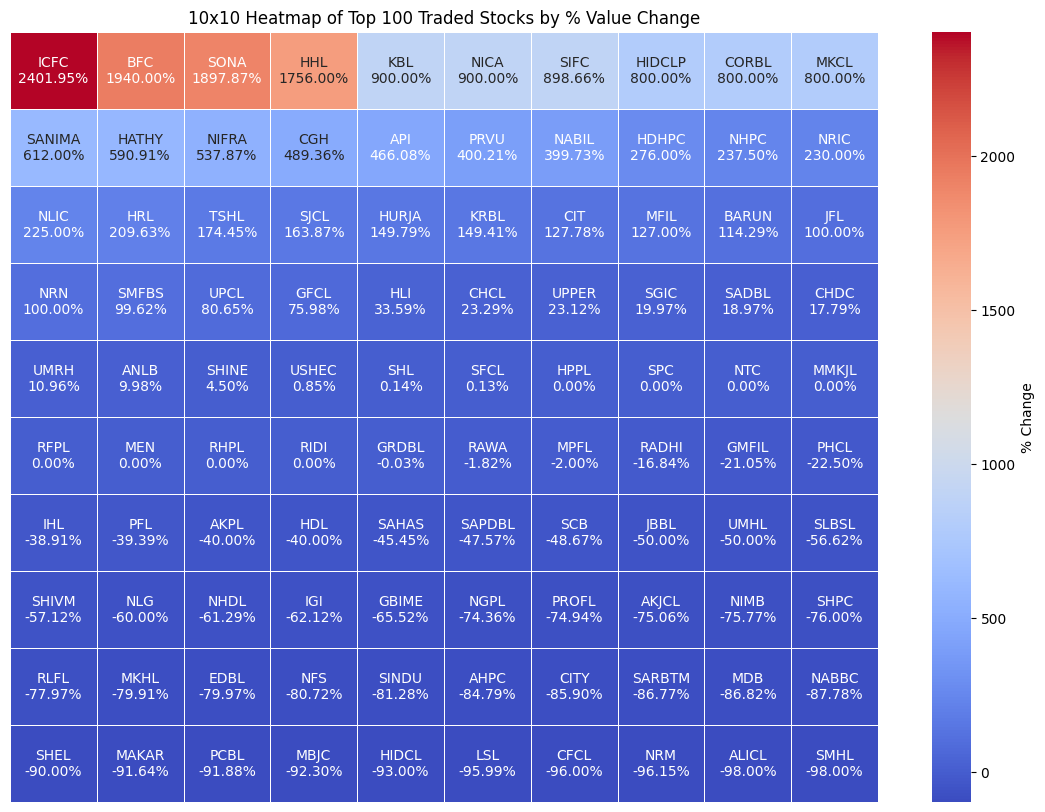

In [126]:

# 2. Compute trading value
df['Value'] = df['Volume'] * df['Rate']

# 3. Compute percentage change in value for each symbol
df['Pct_Change'] = df.groupby('Symbol')['Value'].pct_change() * 100

# 4. Get top 100 traded stocks by total value
top_100 = df.groupby('Symbol')['Value'].sum().nlargest(100).index
top_100_df = df[df['Symbol'].isin(top_100)]

# 5. Get the latest available percentage change per stock
latest_pct_change = top_100_df.sort_values('Ts').groupby('Symbol').tail(1)

# 6. Prepare data for 10x10 heatmap
heatmap_data = latest_pct_change[['Symbol', 'Pct_Change']].set_index('Symbol')
heatmap_matrix = heatmap_data.sort_values('Pct_Change', ascending=False).head(100)

# Pad to ensure 100 items (if less due to missing data)
if len(heatmap_matrix) < 100:
    padding = pd.DataFrame({'Pct_Change': [0]*(100 - len(heatmap_matrix))}, index=[f'NA{i}' for i in range(100 - len(heatmap_matrix))])
    heatmap_matrix = pd.concat([heatmap_matrix, padding])

# Reshape into 10x10 matrix
heatmap_matrix = heatmap_matrix.head(100)
symbols = heatmap_matrix.index.tolist()
values = heatmap_matrix['Pct_Change'].values.reshape(10, 10)

# Annotation with "SYMBOL\nVALUE%"
annotations = np.array([f"{s}\n{v:.2f}%" for s, v in zip(symbols, heatmap_matrix['Pct_Change'])]).reshape(10, 10)

# 7. Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(values, annot=annotations, fmt='', cmap='coolwarm', linewidths=0.5, cbar_kws={'label': '% Change'})
plt.title('10x10 Heatmap of Top 100 Traded Stocks by % Value Change')
plt.axis('off')  # Hide axes ticks

plt.show()


<ipython-input-127-1a9f2de7e7da>:11: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled_data = most_traded_stock_data.resample('T').agg({'Volume': 'sum', 'Rate': 'mean'})


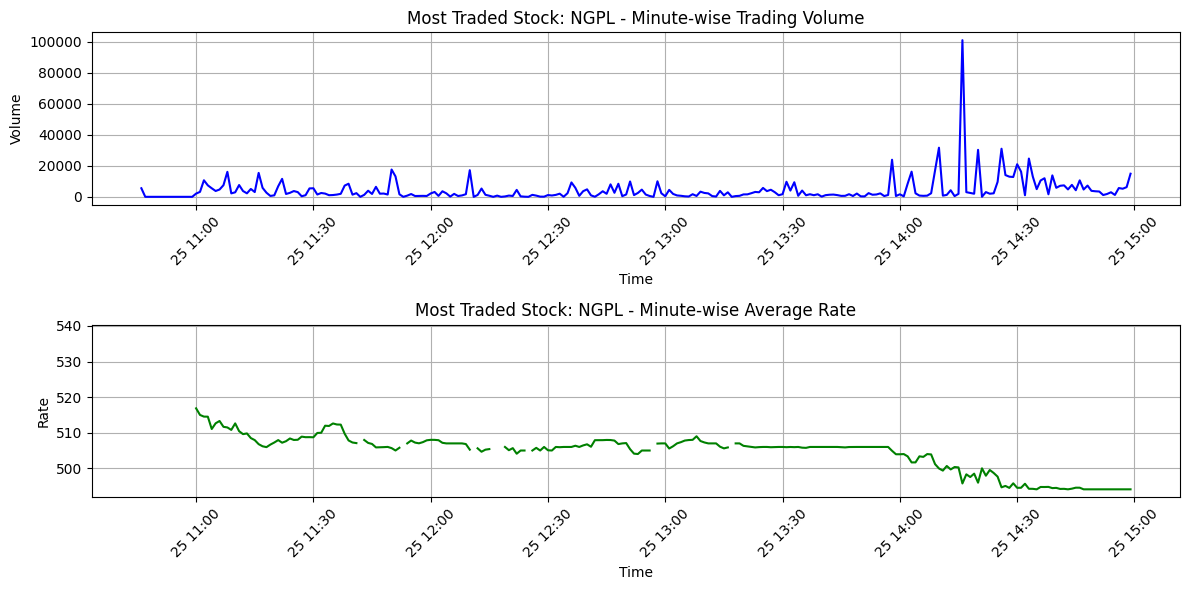

In [127]:
# 1. Identify the most traded stock by total volume
most_traded_stock = df.groupby('Symbol')['Volume'].sum().idxmax()

# 2. Filter data for the most traded stock
most_traded_stock_data = df[df['Symbol'] == most_traded_stock]

# 3. Set the 'Ts' column as the index (needed for resampling)
most_traded_stock_data.set_index('Ts', inplace=True)

# 4. Resample the data by minute and sum the volume (or calculate other metrics like average rate)
resampled_data = most_traded_stock_data.resample('T').agg({'Volume': 'sum', 'Rate': 'mean'})

# 5. Plot the resampled volume or rate data
plt.figure(figsize=(12, 6))

# Plot volume
plt.subplot(2, 1, 1)
plt.plot(resampled_data.index, resampled_data['Volume'], label='Volume', color='blue')
plt.title(f"Most Traded Stock: {most_traded_stock} - Minute-wise Trading Volume")
plt.xlabel('Time')
plt.ylabel('Volume')
plt.xticks(rotation=45)
plt.grid(True)

# Plot average rate (optional)
plt.subplot(2, 1, 2)
plt.plot(resampled_data.index, resampled_data['Rate'], label='Average Rate', color='green')
plt.title(f"Most Traded Stock: {most_traded_stock} - Minute-wise Average Rate")
plt.xlabel('Time')
plt.ylabel('Rate')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()
